In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Manuscript-results synthesis notebook ready")

Manuscript-results synthesis notebook ready


In [2]:
from google.colab import files

uploaded = files.upload()

Saving all_non_iid_results.csv to all_non_iid_results.csv
Saving all_repeated_results.csv to all_repeated_results.csv
Saving combined_communication_results.csv to combined_communication_results.csv
Saving combined_performance_results.csv to combined_performance_results.csv
Saving combined_runtime_results.csv to combined_runtime_results.csv
Saving deployment_tradeoff_matrix.csv to deployment_tradeoff_matrix.csv
Saving non_iid_mean_std_summary.csv to non_iid_mean_std_summary.csv
Saving repeated_experiments_mean_std_summary.csv to repeated_experiments_mean_std_summary.csv


In [3]:
csv_files = sorted([f for f in os.listdir(".") if f.endswith(".csv")])

print("Uploaded CSV files:")
for file in csv_files:
    print("-", file)

print("\nTotal CSV files:", len(csv_files))

Uploaded CSV files:
- all_non_iid_results.csv
- all_repeated_results.csv
- combined_communication_results.csv
- combined_performance_results.csv
- combined_runtime_results.csv
- deployment_tradeoff_matrix.csv
- non_iid_mean_std_summary.csv
- repeated_experiments_mean_std_summary.csv

Total CSV files: 8


In [4]:
iid_summary = pd.read_csv("repeated_experiments_mean_std_summary.csv")
non_iid_summary = pd.read_csv("non_iid_mean_std_summary.csv")

all_iid = pd.read_csv("all_repeated_results.csv")
all_non_iid = pd.read_csv("all_non_iid_results.csv")

combined_performance = pd.read_csv("combined_performance_results.csv")
combined_runtime = pd.read_csv("combined_runtime_results.csv")
combined_communication = pd.read_csv("combined_communication_results.csv")
deployment_tradeoff = pd.read_csv("deployment_tradeoff_matrix.csv")

print("IID repeated-experiment summary")
display(iid_summary)

print("Non-IID repeated-experiment summary")
display(non_iid_summary)

print("Deployment trade-off matrix")
display(deployment_tradeoff)

IID repeated-experiment summary


,Dataset,Method,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,ROC-AUC,Training Time (s)
0,Heart Disease,Centralised LR,0.8400 ± 0.0480,0.8526 ± 0.0382,0.7929 ± 0.0814,0.8208 ± 0.0591,0.8371 ± 0.0500,0.8980 ± 0.0474,0.0017 ± 0.0002
1,Heart Disease,Federated LR (FedAvg),0.8467 ± 0.0477,0.8603 ± 0.0267,0.8000 ± 0.0931,0.8276 ± 0.0603,0.8438 ± 0.0505,0.8984 ± 0.0511,0.0851 ± 0.0108
2,Stroke Prediction,Centralised LR,0.7497 ± 0.0103,0.1250 ± 0.0058,0.8095 ± 0.0673,0.2165 ± 0.0107,0.7783 ± 0.0290,0.8445 ± 0.0225,0.0177 ± 0.0013
3,Stroke Prediction,Federated LR (FedAvg),0.7330 ± 0.0196,0.1164 ± 0.0064,0.7952 ± 0.0852,0.2029 ± 0.0116,0.7627 ± 0.0341,0.8367 ± 0.0233,0.1115 ± 0.0092


Non-IID repeated-experiment summary


,Dataset,Method,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,ROC-AUC,Training Time (s)
0,Heart Disease,Centralised LR,0.8400 ± 0.0480,0.8526 ± 0.0382,0.7929 ± 0.0814,0.8208 ± 0.0591,0.8371 ± 0.0500,0.8980 ± 0.0474,0.0018 ± 0.0004
1,Heart Disease,Federated LR (FedAvg),0.8467 ± 0.0506,0.8661 ± 0.0370,0.7929 ± 0.0924,0.8264 ± 0.0638,0.8433 ± 0.0530,0.8991 ± 0.0504,0.0900 ± 0.0032
2,Stroke Prediction,Centralised LR,0.7497 ± 0.0103,0.1250 ± 0.0058,0.8095 ± 0.0673,0.2165 ± 0.0107,0.7783 ± 0.0290,0.8445 ± 0.0225,0.0190 ± 0.0031
3,Stroke Prediction,Federated LR (FedAvg),0.7825 ± 0.0140,0.1320 ± 0.0102,0.7333 ± 0.0897,0.2236 ± 0.0178,0.7590 ± 0.0396,0.8368 ± 0.0302,0.1219 ± 0.0118


Deployment trade-off matrix


,Method,Training Data Locality,Inference Data Confidentiality,Computation Cost,Communication Cost,Best Suitable Scenario
0,Centralised LR,Low,Low,Low,Low,Trusted central clinical analytics server
1,Federated LR (FedAvg),High,Moderate,Moderate,Moderate to High,Multi-hospital collaborative model training
2,CKKS Encrypted Inference,Moderate,High,High,High per query,Privacy-preserving cloud-based inference


In [5]:
# Extract only FedAvg rows from the raw repeated-experiment results
iid_fedavg = all_iid[
    all_iid["Method"] == "Federated LR (FedAvg)"
].copy()

non_iid_fedavg = all_non_iid[
    all_non_iid["Method"] == "Federated LR (FedAvg)"
].copy()

# Add clear labels
iid_fedavg["Hospital Distribution"] = "IID-like"
non_iid_fedavg["Hospital Distribution"] = "Non-IID"

fedavg_robustness_raw = pd.concat(
    [iid_fedavg, non_iid_fedavg],
    ignore_index=True
)

metrics_for_robustness = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Balanced Accuracy",
    "ROC-AUC",
]

# Numerical mean and standard deviation
robustness_mean = (
    fedavg_robustness_raw
    .groupby(["Dataset", "Hospital Distribution"])[metrics_for_robustness]
    .mean()
)

robustness_std = (
    fedavg_robustness_raw
    .groupby(["Dataset", "Hospital Distribution"])[metrics_for_robustness]
    .std()
)

# Manuscript-ready mean ± standard deviation table
fedavg_robustness_summary = robustness_mean.copy()

for metric in metrics_for_robustness:
    fedavg_robustness_summary[metric] = (
        robustness_mean[metric].map(lambda x: f"{x:.4f}")
        + " ± "
        + robustness_std[metric].map(lambda x: f"{x:.4f}")
    )

fedavg_robustness_summary = fedavg_robustness_summary.reset_index()

print("FedAvg robustness: IID-like versus non-IID hospital distributions")
display(fedavg_robustness_summary)

FedAvg robustness: IID-like versus non-IID hospital distributions


,Dataset,Hospital Distribution,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,ROC-AUC
0,Heart Disease,IID-like,0.8467 ± 0.0477,0.8603 ± 0.0267,0.8000 ± 0.0931,0.8276 ± 0.0603,0.8438 ± 0.0505,0.8984 ± 0.0511
1,Heart Disease,Non-IID,0.8467 ± 0.0506,0.8661 ± 0.0370,0.7929 ± 0.0924,0.8264 ± 0.0638,0.8433 ± 0.0530,0.8991 ± 0.0504
2,Stroke Prediction,IID-like,0.7330 ± 0.0196,0.1164 ± 0.0064,0.7952 ± 0.0852,0.2029 ± 0.0116,0.7627 ± 0.0341,0.8367 ± 0.0233
3,Stroke Prediction,Non-IID,0.7825 ± 0.0140,0.1320 ± 0.0102,0.7333 ± 0.0897,0.2236 ± 0.0178,0.7590 ± 0.0396,0.8368 ± 0.0302


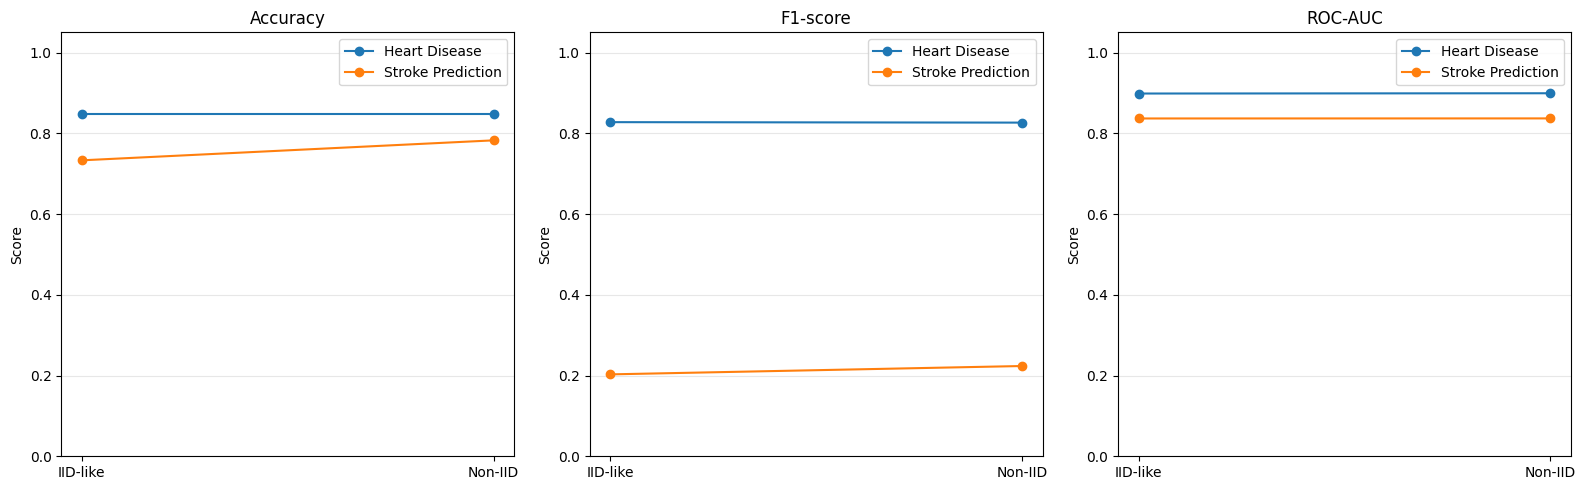

Saved: figure4_fedavg_iid_vs_non_iid_robustness.png


In [6]:
# Figure 4: FedAvg robustness under IID-like vs non-IID hospital distributions

plot_metrics = ["Accuracy", "F1-score", "ROC-AUC"]
datasets = ["Heart Disease", "Stroke Prediction"]
distributions = ["IID-like", "Non-IID"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, plot_metrics):
    for dataset in datasets:
        subset = (
            fedavg_robustness_raw[
                fedavg_robustness_raw["Dataset"] == dataset
            ]
            .groupby("Hospital Distribution")[metric]
            .mean()
            .reindex(distributions)
        )

        ax.plot(
            distributions,
            subset.values,
            marker="o",
            label=dataset
        )

    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.tight_layout()

plt.savefig(
    "figure4_fedavg_iid_vs_non_iid_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figure4_fedavg_iid_vs_non_iid_robustness.png")

In [7]:
fedavg_robustness_summary.to_csv(
    "fedavg_iid_vs_non_iid_robustness_summary.csv",
    index=False
)

print("Saved: fedavg_iid_vs_non_iid_robustness_summary.csv")

Saved: fedavg_iid_vs_non_iid_robustness_summary.csv
